# Exploratory Data Analysis (EDA)

In this notebook, we analyze student social network data to understand distributions, patterns, and relationships between features before clustering.

In [4]:
# Importing the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [10]:
# Load Dataset
df = pd.read_csv("../data/raw/dataset.csv")

In [11]:
# First Five rows
df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [12]:
# Shape of the dataset
df.shape

(15000, 40)

In [41]:
# Checking the column names
df.columns

Index(['gradyear', 'gender', 'age', 'NumberOffriends', 'basketball',
       'football', 'soccer', 'softball', 'volleyball', 'swimming',
       'cheerleading', 'baseball', 'tennis', 'sports', 'cute', 'sex', 'sexy',
       'hot', 'kissed', 'dance', 'band', 'marching', 'music', 'rock', 'god',
       'church', 'jesus', 'bible', 'hair', 'dress', 'blonde', 'mall',
       'shopping', 'clothes', 'hollister', 'abercrombie', 'die', 'death',
       'drunk', 'drugs'],
      dtype='object')

In [ ]:
# Column names cleaning

df.columns = df.columns.str.lower()
df.rename(columns={'numberoffriends': 'number_of_friends'}, inplace=True)

In [13]:
# Checking the info and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           13663 non-null  object
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  int64 
 17  hot              15000 non-null

Interpretation:

- The dataset has missing values in age (~17%) and gender, which need proper imputation before clustering to avoid biased distance calculations.
- The age column is stored as object type instead of numeric, indicating data quality issues that must be corrected by converting it to a numerical format before analysis.

In [16]:
# Changing the dtype of age column
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'].dtype

dtype('float64')

In [17]:
# Checking the statistical summary of dataset
df.describe()

,gradyear,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,15000.000000,12228.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2007.496933,17.988164,29.834533,0.267000,0.255467,0.22200,0.159667,0.142933,0.135000,0.105133,...,0.112867,0.259467,0.357267,0.150267,0.071800,0.051467,0.185867,0.118067,0.091733,0.061067
std,1.116516,7.715857,35.386649,0.788851,0.702260,0.92042,0.737344,0.638747,0.548691,0.502491,...,2.708619,0.704398,0.728512,0.478716,0.356258,0.280755,0.609928,0.455200,0.420631,0.349112
min,2006.000000,4.309000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,16.331000,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.000000,17.295000,20.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,18.264000,44.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2009.000000,106.927000,605.000000,22.000000,9.000000,22.00000,17.000000,14.000000,31.000000,8.000000,...,327.000000,12.000000,11.000000,8.000000,8.000000,8.000000,16.000000,14.000000,8.000000,16.000000


Interpretation:

- The dataset shows a typical student age range around 16–18 years, but the presence of extreme values (up to 106 years) indicates clear outliers or data entry errors in the age feature.
- Most interest-based features are highly zero-inflated (75% = 0), meaning only a small subset of students express strong interest in specific activities, making the dataset highly sparse and suitable for clustering.
- The number of friends varies widely (0 to 605), showing significant variation in social connectivity, which can be an important factor for segmentation.
- Several features have high maximum values compared to their median (e.g., sports and lifestyle terms), indicating strong skewness and presence of outliers, which should be handled before applying distance-based clustering algorithms.

In [18]:
# Checking the statistical summary for categorical columns
df.describe(exclude='number')

,gender
count,13663
unique,2
top,F
freq,11057


Interpretation:

- The dataset is highly imbalanced toward females, with 11,057 out of 13,663 entries (~81%) being female.
- Only two unique gender categories are present, confirming a binary categorical distribution suitable for encoding in clustering preprocessing.
- The remaining missing values in gender (1,337 records) must be handled carefully to avoid introducing bias in clustering results.

In [ ]:
# Checking for null values
df.isnull().sum()

gradyear              0
gender             1337
age                2772
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64

In [23]:
# Imputation for null values

# Since gender was highly imbalanced, I avoided mode imputation to prevent bias
df['gender'] = df['gender'].fillna('Unknown')

# Since the age column is skewed i prefer median over mean
df['age'] = df['age'].fillna(df['age'].median())

### <center>Univariate Analysis</center>

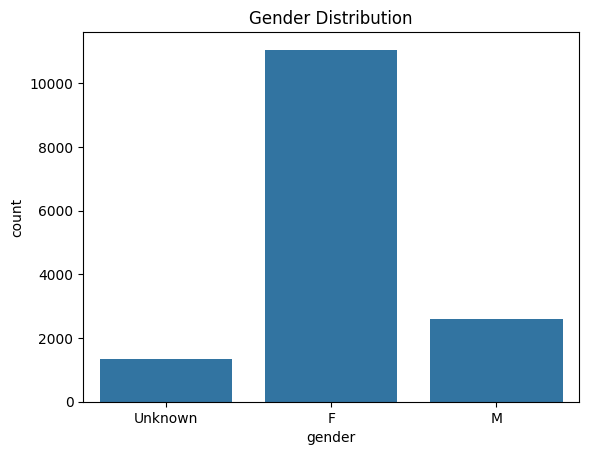

% of Gender Distribution:
gender
F          73.71%
M          17.37%
Unknown     8.91%
Name: proportion, dtype: object


In [38]:
# Gender Distribution

sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

gender_dist = (df['gender'].value_counts(normalize=True) * 100).round(2)

print("% of Gender Distribution:")
print(gender_dist.astype(str) + "%")

Interpretation:

- Female (F): 11,057 (~73.7%) Female Dominance clearly seen
- Male (M): 2,606 (~17.4%)
- Unknown: 1,337 (~8.9%)

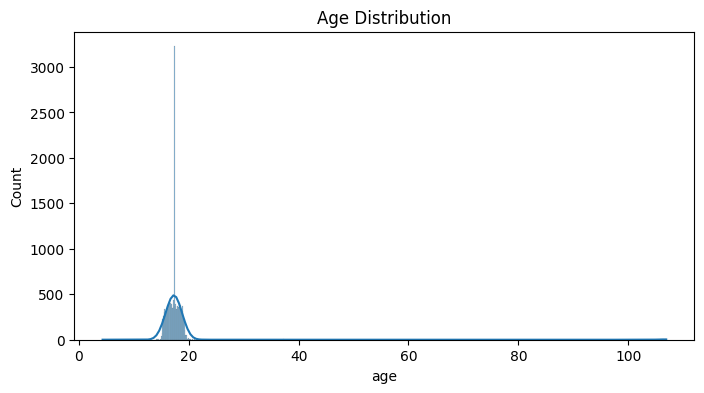

In [30]:
# Age Distribution

plt.figure(figsize=(8,4))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

Interpretation:

- The distribution is seems to be highly positive skewed.
- Most of the students are youngster
- Outliers exists with age greater than 100 clearly its a typo or wrong information.

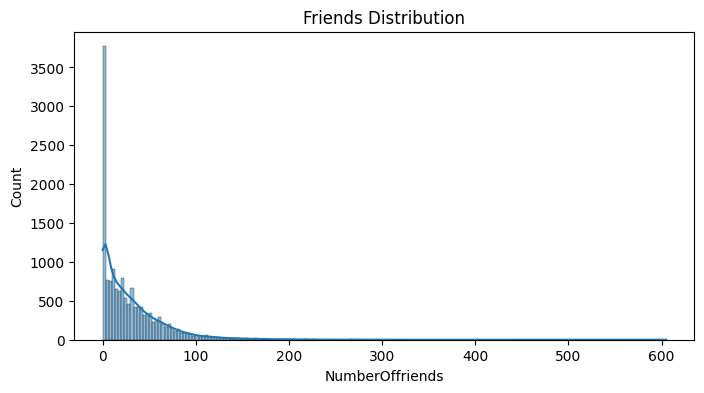

In [ ]:
# Number of Friends Distribution

plt.figure(figsize=(8,4))
sns.histplot(df['number_of_friends'], kde=True)
plt.title("Friends Distribution")
plt.show()

Interpretation:

- Most of the student are socially inactive with 0 friends.
- few are very social with around 600 friends

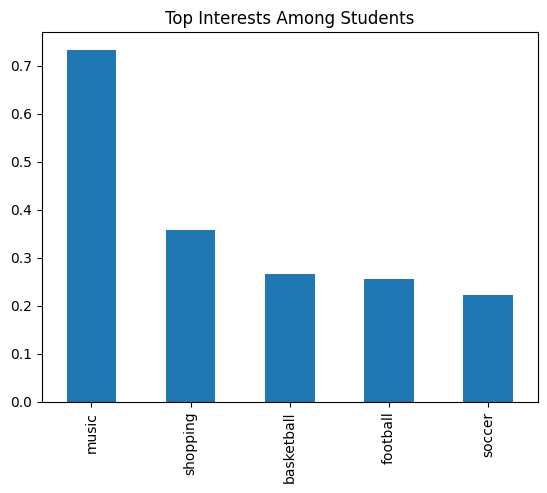

In [50]:
# Top interest featue
interest_cols = ['basketball', 'football', 'soccer', 'music', 'shopping']

df[interest_cols].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Top Interests Among Students")
plt.show()

### <center>Bivariate Analysis</center>

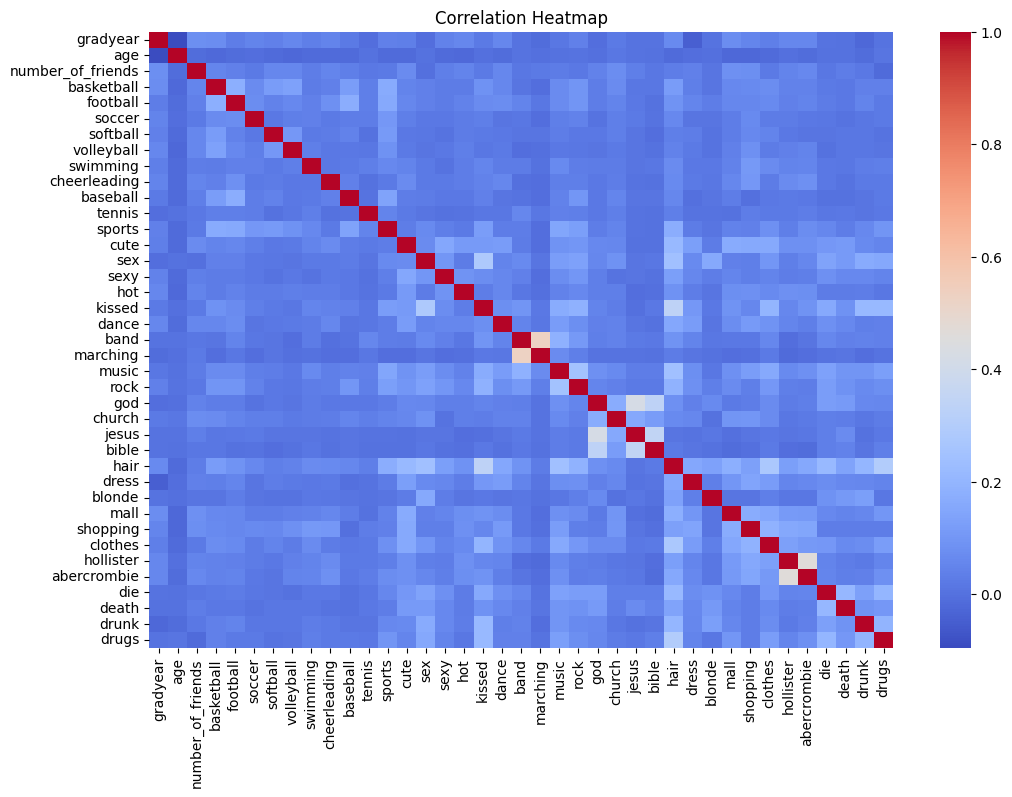

In [51]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [53]:
# Correlation Matrix
df.corr(numeric_only=True)

,gradyear,age,number_of_friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
gradyear,1.000000,-0.094856,0.077816,0.073864,0.032546,0.048606,0.041533,0.058763,0.037188,0.050545,...,0.005064,0.072136,0.051060,0.036288,0.056117,0.058568,0.006026,0.002221,-0.023676,0.006296
age,-0.094856,1.000000,-0.012696,-0.019893,-0.012754,-0.005190,-0.013869,-0.025659,-0.014085,-0.016644,...,-0.000946,-0.023739,-0.026278,-0.015594,-0.002219,-0.009662,0.003347,0.003228,-0.010060,0.008243
number_of_friends,0.077816,-0.012696,1.000000,0.053205,0.041365,0.024091,0.056182,0.058939,0.032515,0.054600,...,0.009628,0.083157,0.076359,0.024381,0.049946,0.059885,0.012731,0.031688,0.019953,-0.017315
basketball,0.073864,-0.019893,0.053205,1.000000,0.178702,0.069133,0.115258,0.134904,0.026544,0.039348,...,0.011045,0.062972,0.064172,0.073477,0.044467,0.045419,0.022670,0.020079,0.038299,0.039564
football,0.032546,-0.012754,0.041365,0.178702,1.000000,0.072336,0.046115,0.061426,0.038702,0.082778,...,0.032439,0.058187,0.055900,0.063497,0.041269,0.047267,0.028447,0.020141,0.049537,0.022025
soccer,0.048606,-0.005190,0.024091,0.069133,0.072336,1.000000,0.019383,0.033457,0.037816,0.021898,...,0.008963,0.029716,0.064759,0.025664,0.027226,0.018477,0.013784,0.007612,0.013351,0.021505
softball,0.041533,-0.013869,0.056182,0.115258,0.046115,0.019383,1.000000,0.102585,0.023841,0.026489,...,0.004897,0.029213,0.062474,0.048564,0.020314,0.011188,0.009762,0.015142,0.013822,0.007445
volleyball,0.058763,-0.025659,0.058939,0.134904,0.061426,0.033457,0.102585,1.000000,0.035109,0.019026,...,0.004201,0.039372,0.081384,0.025691,0.041915,0.047459,0.002995,0.015103,0.014969,0.010785
swimming,0.037188,-0.014085,0.032515,0.026544,0.038702,0.037816,0.023841,0.035109,1.000000,0.020338,...,0.020028,0.044950,0.107169,0.069220,0.048297,0.054437,0.020245,0.012523,0.030401,0.037012
cheerleading,0.050545,-0.016644,0.054600,0.039348,0.082778,0.021898,0.026489,0.019026,0.020338,1.000000,...,0.016116,0.058547,0.103373,0.028279,0.071794,0.081208,0.018031,0.005191,0.023764,0.023449


Interpretation:

The dataset is highly suitable for clustering because:

- Features are mostly independent
- Only small natural groups exist (sports, fashion, lifestyle)
- No single feature dominates relationships

In [55]:
# Checking for outliers
def outlier_summary(df):
    summary = []

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        summary.append({
            "Feature": col,
            "Outlier Count": outliers.shape[0],
            "Outlier %": round((outliers.shape[0] / len(df)) * 100, 2)
        })

    return pd.DataFrame(summary).sort_values(by="Outlier Count", ascending=False)

outlier_summary(df)

,Feature,Outlier Count,Outlier %
27,hair,3407,22.71
18,dance,3323,22.15
13,cute,3114,20.76
30,mall,2633,17.55
4,football,2499,16.66
22,rock,2452,16.35
3,basketball,2412,16.08
19,band,2209,14.73
24,church,2104,14.03
35,die,1980,13.20


In [57]:
# Checking for skewness

skewness = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
skewness

blonde               117.250830
sex                   49.972125
bible                 21.417635
jesus                 19.160195
swimming              16.380904
kissed                12.866542
drugs                 12.508258
marching              11.670519
age                   11.664522
god                   11.490218
tennis                11.236150
baseball               9.344208
abercrombie            8.169792
death                  8.104098
softball               7.842373
hollister              7.788430
volleyball             7.548032
drunk                  7.545941
band                   7.413696
soccer                 7.277183
die                    6.993131
cheerleading           6.917809
sexy                   6.678510
rock                   6.450876
sports                 5.877223
dance                  5.728317
hot                    5.685510
basketball             5.681317
church                 5.549156
dress                  5.546623
mall                   4.697283
hair    

Interpretation:

- This dataset is not normally distributed, which is completely expected for social interest data.
- High skewness indicates sparse user behavior patterns, where most students do not mention most interests.
- This structure is actually ideal for clustering, because it creates natural separation between user groups.

### Overall Data Insights
- The dataset contains 15,000 high school student profiles with a mix of demographic and interest-based features, making it highly suitable for behavioral segmentation using clustering techniques.
- Most interest-related attributes are highly sparse and right-skewed, indicating that only a small subset of students actively engage or mention specific interests, while the majority show zero or low activity.
- Features naturally form latent groups such as sports interests, lifestyle/fashion interests, and religion-related interests, suggesting the presence of meaningful hidden clusters in the data.
- Demographic variables like age, gradyear, and number_of_friends are relatively well distributed, but do not strongly dominate behavioral patterns.
- The dataset contains moderate outliers and extreme values, which are not errors but represent highly active or expressive users within specific interest categories.

### Final Interpretation:
The dataset is ideal for unsupervised learning (clustering) due to:

- High dimensionality (40 features)
- Sparse behavioral patterns
- Natural grouping tendencies
- Weak linear correlations between most variables

In [58]:
# Saving the processed Dataset
df.to_csv("../data/processed/students_cleaned.csv", index=False)